In [1]:
import pandas as pd
import numpy as np


from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [2]:
import os
print(os.getcwd())

C:\Users\Analysis_VM\Desktop\Ransomware_Project\notebooks


In [3]:
df = pd.read_csv("../data/pe_features(New).csv")
df.head()

,sha256,file_name,family,file_size,num_sections,many_sections,size_of_image,size_of_code,entry_point,num_imports,num_dlls,avg_entropy,max_entropy,min_entropy,has_crypto,has_bcrypt,has_file_ops,label
0,fac81bcdcb6ccf8505dfa44a9b4756a50e67b89f8c8fcf...,3uTools.exe,benign,13675880,6,0,13672448,9740288,8547568,4313,51,5.135459,6.374358,2.818603,0,0,1,0
1,8fdeb6c13162c9398e97b66c4f0a780c1e270e300a637e...,3uViewer.exe,benign,989928,6,0,978944,54784,51084,693,22,4.562831,6.085465,3.433966,0,0,0,0
2,7faad7057f2f88a431803c32fb7d272199bba89de3dc60...,7z.exe,benign,492608,6,0,491520,318976,319776,127,5,4.300758,6.285946,1.232928,0,0,1,0
3,0a038cc8dc46b6d50245c6951dc238fba63654a0cb3d23...,CrashReport.exe,benign,971992,5,0,970752,561664,383673,279,12,5.502765,6.607745,4.518242,0,0,0,0
4,b58aeb18d26cfd9b63c9ccfa0ebfe40d9ab7a01b4c9856...,InfInstallerx64.exe,benign,217152,6,0,221184,135680,56616,107,5,4.909627,6.413611,3.484201,0,0,0,0


In [4]:
df.shape

(1649, 18)

In [5]:
df["label"].value_counts()

label
0    936
1    713
Name: count, dtype: int64

In [6]:
print(df.columns)

Index(['sha256', 'file_name', 'family', 'file_size', 'num_sections',
       'many_sections', 'size_of_image', 'size_of_code', 'entry_point',
       'num_imports', 'num_dlls', 'avg_entropy', 'max_entropy', 'min_entropy',
       'has_crypto', 'has_bcrypt', 'has_file_ops', 'label'],
      dtype='str')


In [7]:
df = df.drop(["sha256","file_name","family"], axis=1)
df.head()

,file_size,num_sections,many_sections,size_of_image,size_of_code,entry_point,num_imports,num_dlls,avg_entropy,max_entropy,min_entropy,has_crypto,has_bcrypt,has_file_ops,label
0,13675880,6,0,13672448,9740288,8547568,4313,51,5.135459,6.374358,2.818603,0,0,1,0
1,989928,6,0,978944,54784,51084,693,22,4.562831,6.085465,3.433966,0,0,0,0
2,492608,6,0,491520,318976,319776,127,5,4.300758,6.285946,1.232928,0,0,1,0
3,971992,5,0,970752,561664,383673,279,12,5.502765,6.607745,4.518242,0,0,0,0
4,217152,6,0,221184,135680,56616,107,5,4.909627,6.413611,3.484201,0,0,0,0


In [8]:
X = df.drop("label", axis=1)
y = df["label"]

In [9]:
# ============================================
# CELL: Train/Test Split
# Purpose:
# Split dataset while preserving class distribution
# ============================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("[INFO] Train/Test split completed")
print(f"[INFO] Train samples: {len(X_train)}")
print(f"[INFO] Test samples: {len(X_test)}")

[INFO] Train/Test split completed
[INFO] Train samples: 1319
[INFO] Test samples: 330


In [10]:
# ============================================
# CELL: Feature Scaling
# Purpose:
# Scale numerical features for distance-based models
# ============================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("[INFO] Scaling completed")

[INFO] Scaling completed


In [11]:
!py -m pip install seaborn


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: C:\Users\Analysis_VM\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


In [12]:
#Compare between models 

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score

models = { 
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=3000)
}

In [13]:
# ============================================
# CELL: Train ML Models
# Purpose:
# Train and evaluate multiple ML algorithms
# ============================================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

NEEDS_SCALING = {
    "Logistic Regression",
    "KNN"
}

results = {}

for name, model in models.items():

    print(f"\n[INFO] Training: {name}")

    if name in NEEDS_SCALING:

        model.fit(X_train_scaled, y_train)

        pred = model.predict(X_test_scaled)

        prob = model.predict_proba(X_test_scaled)[:, 1]

    else:

        model.fit(X_train, y_train)

        pred = model.predict(X_test)

        prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    roc_auc = roc_auc_score(y_test, prob)

    results[name] = {
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC-AUC": roc_auc
    }

    print(classification_report(y_test, pred))

    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")


[INFO] Training: Random Forest
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       187
           1       1.00      0.97      0.99       143

    accuracy                           0.99       330
   macro avg       0.99      0.99      0.99       330
weighted avg       0.99      0.99      0.99       330

Accuracy : 0.9879
Precision: 1.0000
Recall   : 0.9720
F1 Score : 0.9858
ROC-AUC  : 0.9996

[INFO] Training: Decision Tree
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       187
           1       0.95      0.97      0.96       143

    accuracy                           0.97       330
   macro avg       0.97      0.97      0.97       330
weighted avg       0.97      0.97      0.97       330

Accuracy : 0.9667
Precision: 0.9521
Recall   : 0.9720
F1 Score : 0.9619
ROC-AUC  : 0.9673

[INFO] Training: KNN
              precision    recall  f1-score   support

           0       0.96  

In [14]:
# ============================================
# CELL: Cross Validation
# Purpose:
# Measure model stability using Stratified K-Fold
# ============================================

from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=cv,
    scoring="f1"
)

print("[INFO] Cross Validation Results")
print(f"[INFO] Scores: {scores}")
print(f"[INFO] Mean F1: {scores.mean():.4f}")
print(f"[INFO] Std F1 : {scores.std():.4f}")

[INFO] Cross Validation Results
[INFO] Scores: [0.97491039 0.95104895 0.97508897 0.97202797 0.97526502]
[INFO] Mean F1: 0.9697
[INFO] Std F1 : 0.0094


In [15]:
import joblib
from sklearn.ensemble import RandomForestClassifier

final_model = RandomForestClassifier(n_estimators=200, random_state=42)
final_model.fit(X_train, y_train)

FEATURE_COLUMNS = X.columns.tolist()

joblib.dump(
    {
        "model": final_model,
        "features": FEATURE_COLUMNS
    },
    "model.pkl"
)

print("[SUCCESS] Model saved")


[SUCCESS] Model saved


In [16]:
# ============================================
# CELL: Save Feature Scaler
# Purpose:
# Save trained scaler for inference
# ============================================

import joblib

joblib.dump(
    scaler,
    "scaler.pkl"
)

print("[SUCCESS] Scaler saved")

[SUCCESS] Scaler saved


In [17]:
# ============================================
# CELL: Prediction Feature Extraction
# Purpose:
# Extract EXACT SAME features used during training
# ============================================

import pefile
import numpy as np
import math
import os

from collections import Counter


def calculate_entropy(data):

    if not data:
        return 0.0

    counter = Counter(data)

    length = len(data)

    entropy = 0

    for count in counter.values():

        p = count / length

        entropy -= p * math.log2(p)

    return entropy


def extract_features(file_path):

    try:

        pe = pefile.PE(file_path)

        file_size = os.path.getsize(file_path)

        num_sections = pe.FILE_HEADER.NumberOfSections

        many_sections = int(num_sections > 6)

        size_of_image = pe.OPTIONAL_HEADER.SizeOfImage

        size_of_code = pe.OPTIONAL_HEADER.SizeOfCode

        entry_point = pe.OPTIONAL_HEADER.AddressOfEntryPoint

        num_imports = 0

        num_dlls = 0

        has_crypto = 0

        has_bcrypt = 0

        has_file_ops = 0

        suspicious_crypto = {
            "CryptEncrypt",
            "CryptDecrypt",
            "BCryptEncrypt",
            "BCryptDecrypt"
        }

        suspicious_file_ops = {
            "CreateFileW",
            "WriteFile",
            "ReadFile"
        }

        if hasattr(pe, "DIRECTORY_ENTRY_IMPORT"):

            num_dlls = len(pe.DIRECTORY_ENTRY_IMPORT)

            for entry in pe.DIRECTORY_ENTRY_IMPORT:

                dll_name = entry.dll.decode(errors="ignore").lower()

                for imp in entry.imports:

                    if imp.name:

                        api = imp.name.decode(errors="ignore")

                        num_imports += 1

                        if api in suspicious_crypto:

                            has_crypto = 1

                        if "bcrypt" in dll_name:

                            has_bcrypt = 1

                        if api in suspicious_file_ops:

                            has_file_ops = 1

        entropies = [
            calculate_entropy(s.get_data())
            for s in pe.sections
        ]

        avg_entropy = np.mean(entropies) if entropies else 0.0

        max_entropy = np.max(entropies) if entropies else 0.0

        min_entropy = np.min(entropies) if entropies else 0.0

        return np.array([

            file_size,
            num_sections,
            many_sections,
            size_of_image,
            size_of_code,
            entry_point,
            num_imports,
            num_dlls,
            avg_entropy,
            max_entropy,
            min_entropy,
            has_crypto,
            has_bcrypt,
            has_file_ops

        ]).reshape(1, -1)

    except Exception as e:

        print("Error:", e)

        return None

In [27]:
#Predection

import joblib
import numpy as np
import pandas as pd

def predict(file_path):

    saved = joblib.load("model.pkl")

    model = saved["model"]

    features = extract_features(file_path)

    if features is None:

        return "Invalid PE File"

    features = pd.DataFrame(

        features,

        columns=FEATURE_COLUMNS

    )

    prediction = model.predict(features)[0]

    prob = model.predict_proba(features)[0]

    confidence = max(prob) * 100

    if prediction == 1:

        return f"RANSOMWARE ({confidence:.2f}%)"

    else:

        print("Probabilities:", prob)

        return f"BENIGN ({confidence:.2f}%)"

In [28]:
# ============================================
# CELL: Inference Test
# Purpose:
# Test model on unseen PE files
# ============================================

test_files = [

    "../test_samples/notepad++.exe", # Benign file

    "../test_samples/12bba7161d07efcb1b14d30054901ac9ffe5202972437b0c47c88d71e45c7176.exe", # Ransomware file

    "../test_samples/obs64.exe" # Packed_bengin file

]

for file in test_files:

    print("\n" + "=" * 50)

    print("File:", file)

    result = predict(file)

    print("Prediction:", result)


File: ../test_samples/notepad++.exe
Probabilities: [0.995 0.005]
Prediction: BENIGN (99.50%)

File: ../test_samples/12bba7161d07efcb1b14d30054901ac9ffe5202972437b0c47c88d71e45c7176.exe
Prediction: RANSOMWARE (63.00%)

File: ../test_samples/obs64.exe
Probabilities: [0.925 0.075]
Prediction: BENIGN (92.50%)


In [19]:
# ============================================
# CELL: Feature Importance
# Purpose:
# Understand which features affect predictions most
# ============================================

import pandas as pd

importance_df = pd.DataFrame({

    "Feature": FEATURE_COLUMNS,

    "Importance": final_model.feature_importances_

})

importance_df = importance_df.sort_values(

    by="Importance",

    ascending=False

)

print(importance_df)

          Feature  Importance
7        num_dlls    0.149949
9     max_entropy    0.138946
6     num_imports    0.103694
5     entry_point    0.101058
0       file_size    0.094407
8     avg_entropy    0.092450
3   size_of_image    0.087043
10    min_entropy    0.072233
4    size_of_code    0.067625
1    num_sections    0.044392
13   has_file_ops    0.020733
2   many_sections    0.011007
11     has_crypto    0.010057
12     has_bcrypt    0.006407


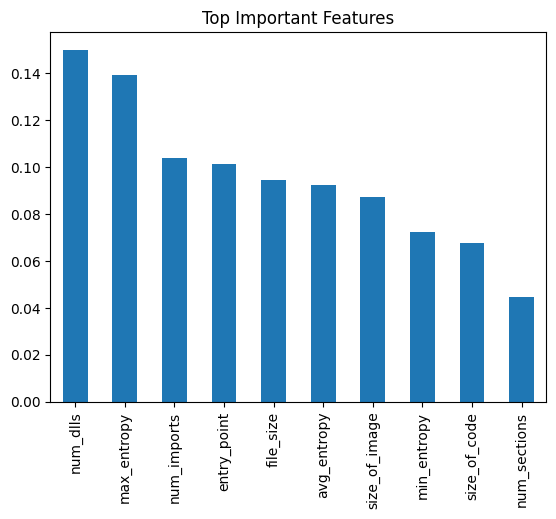

In [20]:
# ============================================
# CELL: Feature Importance Plot
# Purpose:
# Visualize most important features
# ============================================

import pandas as pd
import matplotlib.pyplot as plt

importance = final_model.feature_importances_

feat = pd.Series(

    importance,

    index=FEATURE_COLUMNS

)

feat.sort_values(

    ascending=False

).head(10).plot(kind="bar")

plt.title("Top Important Features")

plt.show()

In [21]:
# ============================================
# CELL: Final Model Evaluation
# Purpose:
# Evaluate final RandomForest model
# ============================================

from sklearn.metrics import (

    accuracy_score,
    precision_score,
    recall_score,
    f1_score

)

y_pred = final_model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))

print("Precision:", precision_score(y_test, y_pred))

print("Recall   :", recall_score(y_test, y_pred))

print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.996969696969697
Precision: 1.0
Recall   : 0.993006993006993
F1 Score : 0.9964912280701754


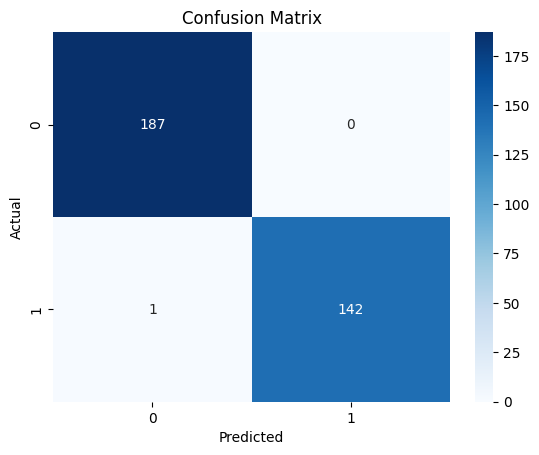

In [22]:
# ============================================
# CELL: Confusion Matrix
# Purpose:
# Visualize classification performance
# ============================================

from sklearn.metrics import confusion_matrix

import seaborn as sns

import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()